<a href="https://colab.research.google.com/github/aabbell/licence/blob/main/Copy_of_Yolorps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="m4X06xxBBHDL7HN364GN")
project = rf.workspace("abels-workspace").project("license-plate-recognition-rxg4e-hhu4y")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
DATASET_PATH = "/content/License-Plate-Recognition-1"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

print(DATA_YAML)

/content/License-Plate-Recognition-1/data.yaml


In [ ]:
models = {
    "YOLOv8n": YOLO("yolov8n.pt"),
    "YOLOv8s": YOLO("yolov8s.pt"),
    "YOLOv8m": YOLO("yolov8m.pt")
}

In [ ]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']

# Store results
all_metrics = {}

for name, model in models.items():
    print(f"Validating {name}...")
    metrics = model.val(data=DATA_YAML)

    all_metrics[name] = [
        metrics.box.map50,  # mAP@50
        metrics.box.map,    # mAP@50-95
        metrics.box.mp,     # Precision
        metrics.box.mr      # Recall
    ]

Validating YOLOv8n...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1209.8±349.1 MB/s, size: 41.3 KB)
val: Scanning /content/License-Plate-Recognition-1/valid/labels... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 2.2Kit/s 0.9s
val: New cache created: /content/License-Plate-Recognition-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 5.5it/s 23.3s
                   all       2048       2195   0.000702     0.0128   0.000356   0.000189
                person       2045       2195   0.000702     0.0128   0.000356   0.000189
Speed: 1.4ms preprocess, 3.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val2
Validating YOLOv8s...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10

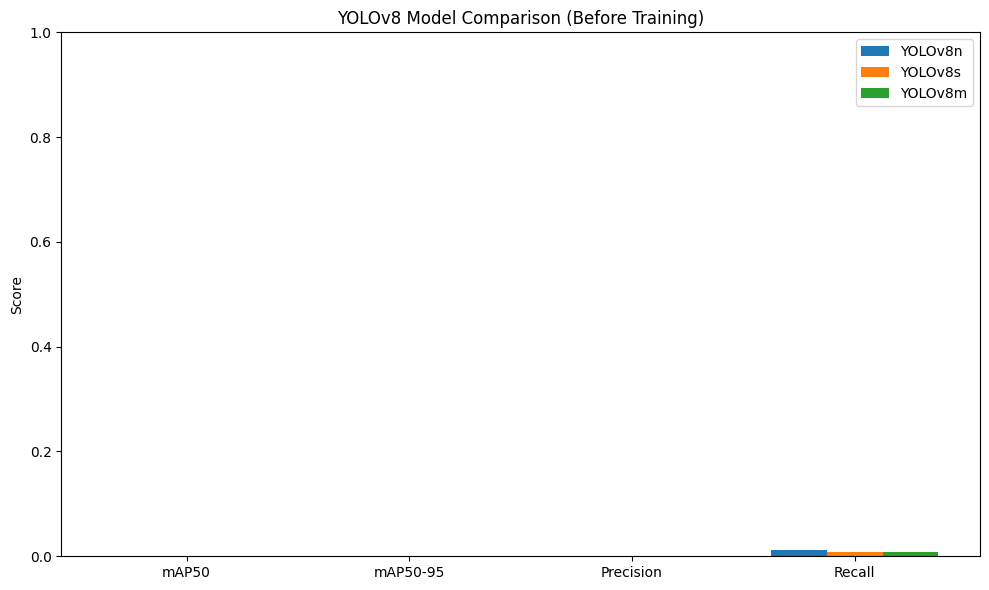

In [ ]:
x = np.arange(len(metrics_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, all_metrics["YOLOv8n"], width, label='YOLOv8n')
rects2 = ax.bar(x, all_metrics["YOLOv8s"], width, label='YOLOv8s')
rects3 = ax.bar(x + width, all_metrics["YOLOv8m"], width, label='YOLOv8m')

ax.set_ylabel('Score')
ax.set_title('YOLOv8 Model Comparison (Before Training)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.0)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...")

    results = model.train(
        data=DATA_YAML,
        epochs=5,
        imgsz=640,
        batch=16,
        name=f"licence_yolo_{name}",  # IMPORTANT: unique name
        exist_ok=True
    )


Training YOLOv8n...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=licence_yolo_YOLOv8n, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [ ]:
all_metrics_after = {}

for name in model:
    print(f"\nValidating {name}...")

    model_path = f"runs/detect/licence_yolo_{name}/weights/best.pt"
    trained_model = YOLO(model_path)

    metrics = trained_model.val(data=DATA_YAML)
    all_metrics_after[name] = [
        metrics.box.map50,   # mAP@50
        metrics.box.map,     # mAP@50-95
        metrics.box.mp,      # Precision
        metrics.box.mr       # Recall
        ]

In [ ]:
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)